# Evolving a hyperbolic LCS as a material curve

An extracted hyperbolic LCS is a **material** curve: once we have its vertices
at $t_0$ (the `lon`/`lat` that `shrink_lines` returns), its position at any
other time is fixed by the flow, $\mathcal{M}(t) = F_{t_0}^{t}(\mathcal{M}(t_0))$
(Haller 2015, Eq. 5). We do not re-diagnose the LCS — we watch one fixed curve
move.

The flow map $F_{t_0}^{t}$ *is* the advected-position field a `FlowMap` stores,
so evolving the curve is interpolating that field at the curve's vertices with
`FlowMap.image` — no re-integration of the curve, and self-consistent with the
map that diagnosed it. Each family is evolved in its **coherent** direction,
where perturbations decay: an attracting LCS attracts forward in time, a
repelling LCS attracts backward. So the attracting curve is carried by the
forward maps and the repelling curve by the backward maps.

It reads the bundled current subset, so it runs offline. Run with
`pixi run -e examples jupytext --sync --execute examples/cabo_verde_lcs_evolution.py`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from parcels import FieldSet, ParticleSet, Particle, StatusCode
from parcels.kernels import AdvectionRK4
from parcels.convert import copernicusmarine_to_sgrid

from lcs_parcels import NeighborSeed, ftle_ridge_seeds, shrink_lines

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_50821/3746538781.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, ParticleSet, Particle, StatusCode


## Currents

The bundled CMEMS hourly surface velocity, wrapped as a spherical `FieldSet`.

In [2]:
currents = xr.open_dataset("data/cabo_verde_currents_hourly.nc")
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed and horizons

A rectilinear `NeighborSeed` over the release box, anchored at the middle of the
bundled window. We evolve out to two horizons, $\tfrac{T}{2}$ and $T$, in each
direction; the longest is where we diagnose the LCS.

In [3]:
t0 = np.datetime64("2025-08-06")
leads = np.array([np.timedelta64(60, "h"), np.timedelta64(120, "h")])  # +2.5 d, +5 d
resolution_deg = 1 / 25
seed_lon, seed_lat = (-27.0, -21.0), (13.5, 18.5)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeed.from_axes(lon_axis, lat_axis)

In [4]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect to each horizon

One advection of the seed grid per horizon and direction, ingested into a
`FlowMap`. The recovery kernel turns lost particles into `NaN` so losses
propagate; the longest-window map of each direction feeds the diagnosis, the
shorter ones serve only as position maps for the evolution.

In [5]:
def advect(signed_T):
    lon, lat = seed.to_parcels_pset()
    pset = ParticleSet(
        fieldset, pclass=Particle,
        x=lon, y=lat, z=np.full(len(lon), z_surface), t=np.full(len(lon), t0),
    )
    dt = np.timedelta64(1, "h") if signed_T > np.timedelta64(0) else np.timedelta64(-1, "h")
    pset.execute([AdvectionRK4, set_lost_to_nan], dt=dt, runtime=abs(signed_T),
                 verbose_progress=False)
    return seed.pset_to_flowmap(pset.x, pset.y, t0=t0, t1=t0 + signed_T)


forward_maps = [advect(+lead) for lead in leads]
backward_maps = [advect(-lead) for lead in leads]
forward, backward = forward_maps[-1], backward_maps[-1]

## Extract the LCS at the longest window

The ridges are sharpest at $T$, so we diagnose there: repelling LCS from the
forward flow, attracting from the backward one (Haller–Sapsis duality), each
seeded at the local maxima of its own FTLE.

In [6]:
def ftle_per_day(flowmap):
    return (flowmap.ftle() * 86400.0).rename("FTLE")


repelling = shrink_lines(forward, *ftle_ridge_seeds(ftle_per_day(forward)))
attracting = shrink_lines(backward, *ftle_ridge_seeds(ftle_per_day(backward)))
print(f"{repelling.sizes['line']} repelling, {attracting.sizes['line']} attracting lines")

54 repelling, 51 attracting lines


## Evolve each family in its coherent direction

`FlowMap.image` interpolates a flow map at the curve's vertices. We stack the
curve at $t_0$ (lead 0) with its image under each horizon map into an evolution
cube `lon`/`lat` on `(lead, line, point)`, `lead` being the signed offset from
$t_0$ in days. The attracting curve rides the forward maps, the repelling curve
the backward maps.

In [7]:
def evolve(curve, maps):
    frames = [curve[["lon", "lat"]]]
    lead_days = [0.0]
    for m in maps:
        frames.append(m.image(curve["lon"], curve["lat"]))
        lead_days.append(float(m.ds["T"] / np.timedelta64(1, "D")))
    return xr.concat(frames, dim="lead").assign_coords(lead=("lead", lead_days))


attracting_evo = evolve(attracting, forward_maps)
repelling_evo = evolve(repelling, backward_maps)

## Snapshots

Each family at $t_0$, half, and full window, with the $t_0$ position drawn
faintly for reference.

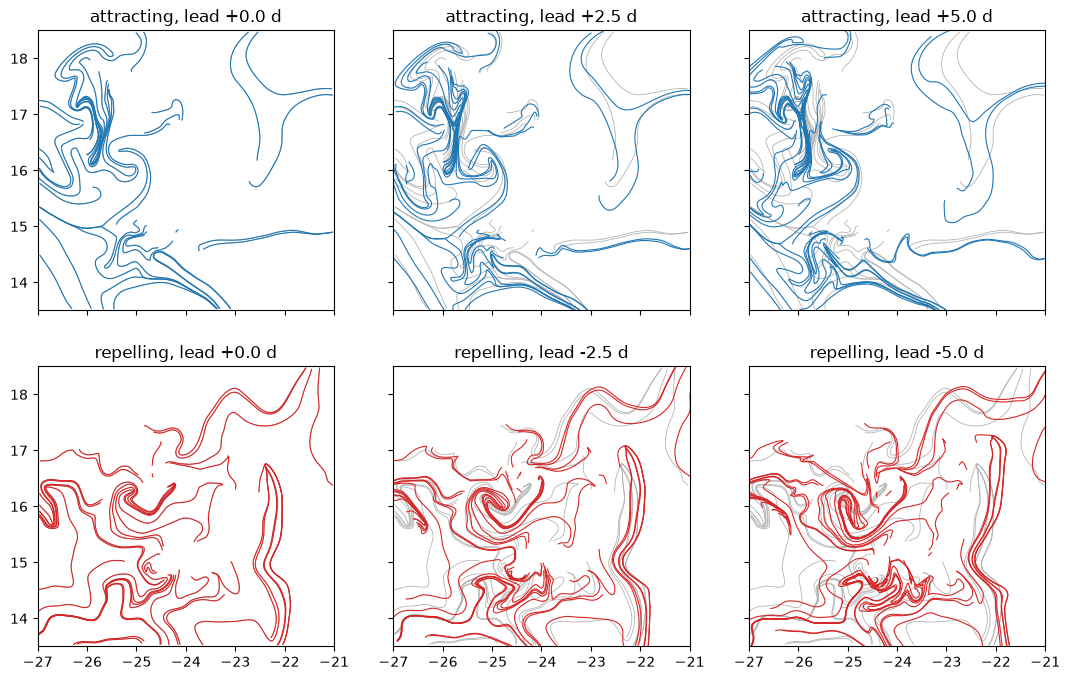

In [8]:
families = [
    (attracting_evo, "tab:blue", "attracting"),
    (repelling_evo, "tab:red", "repelling"),
]
fig, axes = plt.subplots(2, attracting_evo.sizes["lead"], figsize=(13, 8),
                         sharex=True, sharey=True)
for row, (evo, color, name) in zip(axes, families):
    for ax, k in zip(row, range(evo.sizes["lead"])):
        for lon0, lat0 in zip(evo["lon"].isel(lead=0), evo["lat"].isel(lead=0)):
            ax.plot(lon0, lat0, color="0.7", lw=0.6)
        for lon_line, lat_line in zip(evo["lon"].isel(lead=k), evo["lat"].isel(lead=k)):
            ax.plot(lon_line, lat_line, color=color, lw=0.8)
        ax.set_title(f"{name}, lead {evo['lead'].isel(lead=k).item():+.1f} d")
        ax.set_xlim(seed_lon)
        ax.set_ylim(seed_lat)